# Backbone Ablation

This notebook loads the Excel result workbooks from `results/*.xlsx` and renders only the backbone-ablation bar summary and depth-profile curve plots. Heatmaps and LTX-only sections are intentionally omitted.


# Backbone Ablation: Bars and Curves

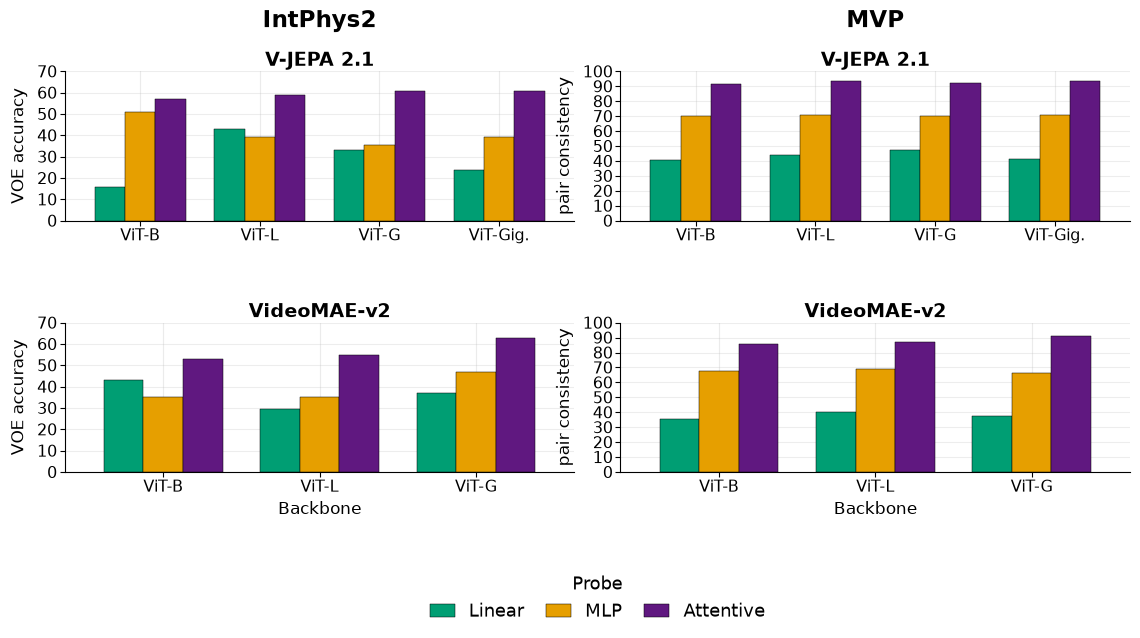

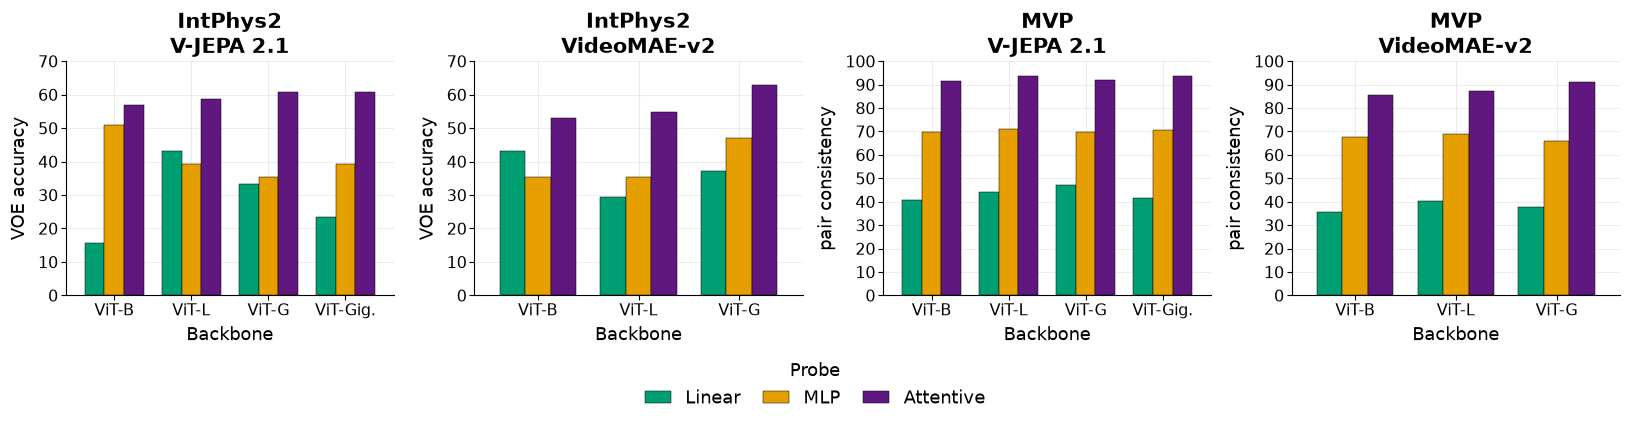

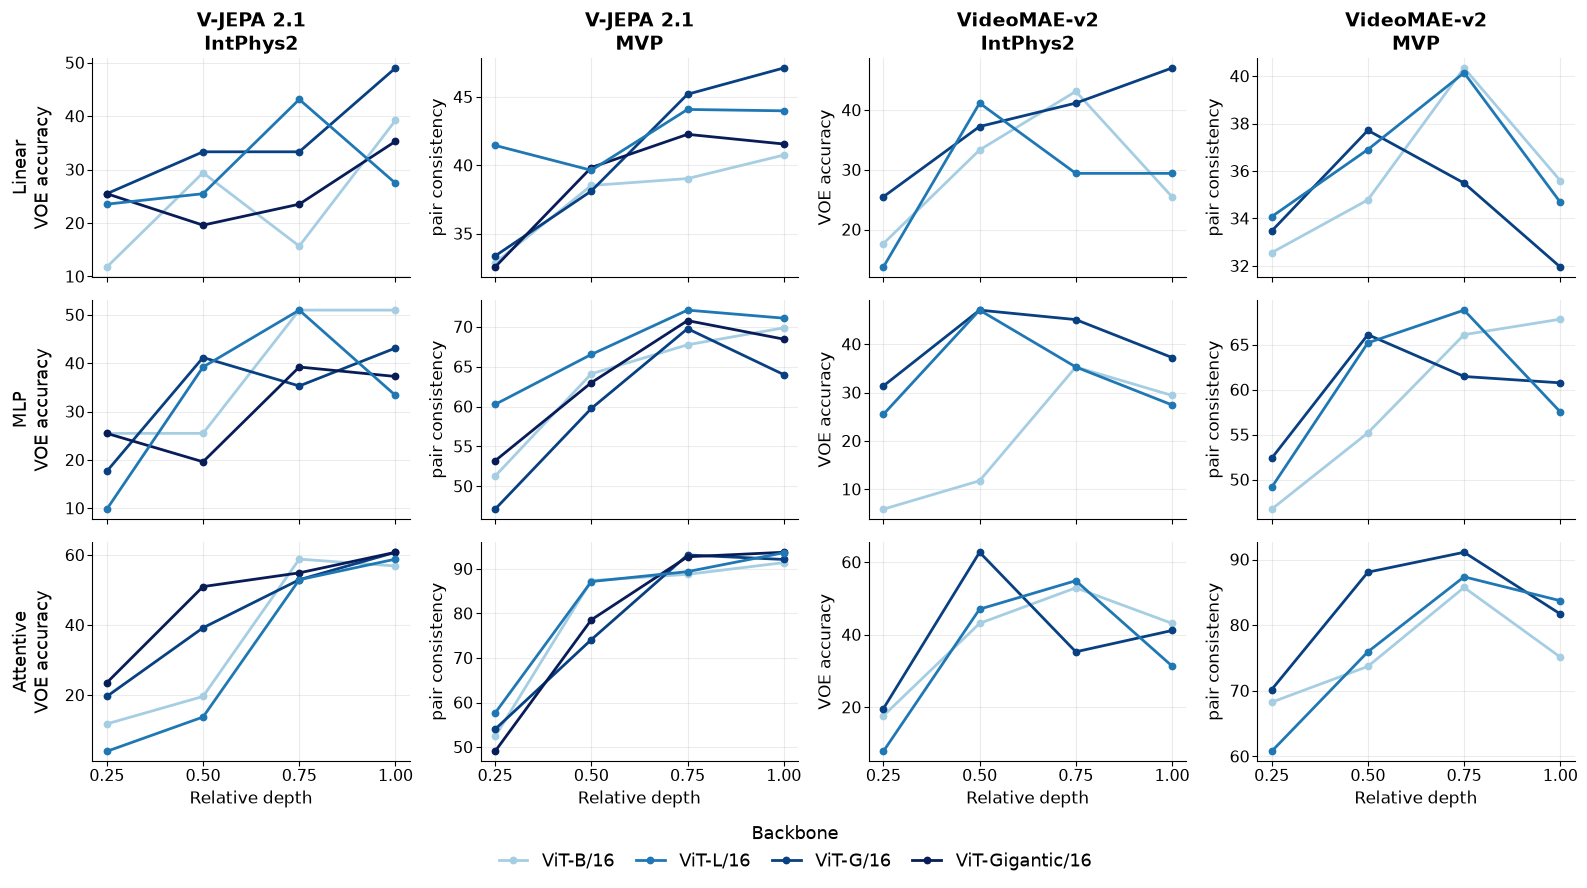

In [7]:
from pathlib import Path
import os
import re
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/probe4physics_matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp/probe4physics_cache')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from IPython.display import Markdown, display
except ModuleNotFoundError:
    class Markdown(str):
        pass
    def display(obj):
        print(obj)

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 180)
if sns is not None:
    sns.set_theme(style='whitegrid', context='notebook')
else:
    plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.25})
plt.rcParams['figure.max_open_warning'] = 0

def find_repo_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    for candidate in [current, *current.parents]:
        if (candidate / 'results').exists() and (candidate / 'run.py').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root containing results/ and run.py')

REPO_ROOT = find_repo_root()
NOTEBOOK_DIR = REPO_ROOT / 'notebooks'
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
import importlib
import plot_colors
importlib.reload(plot_colors)
from plot_colors import BACKBONE_COLORS, FAMILY_COLORS, MODEL_COLORS, PROBE_COLORS, PROBE_LABEL_COLORS

RESULTS_DIR = REPO_ROOT / 'results'
MVP_XLSX = RESULTS_DIR / 'mvp_primary_db.xlsx'
INTPHYS_XLSX = RESULTS_DIR / 'intphys_primary_db.xlsx'

DATASET_ORDER = ['intphys2', 'mvp']
DATASET_LABEL = {'mvp': 'MVP', 'intphys2': 'IntPhys2'}
PRIMARY_LABEL = {'mvp': 'pair consistency', 'intphys2': 'VOE accuracy'}
PROBE_ORDER = ['linear', 'mlp', 'temporal_attn']
PROBE_LABEL = {'linear': 'Linear', 'mlp': 'MLP', 'temporal_attn': 'Attentive'}
ABLATION_MODELS = ['jepa_v2_1', 'videomae_v2']
MODEL_LABEL = {'jepa_v2_1': 'V-JEPA 2.1', 'videomae_v2': 'VideoMAE-v2', 'ltx_video': 'LTX-Video'}
MODEL_FAMILY = {'jepa_v2_1': 'V-JEPA', 'videomae_v2': 'VideoMAE', 'ltx_video': 'LTX-Video'}
SHEET_TO_MODEL_KEY = {
    'V-JEPA': 'jepa_v1',
    'V-JEPA 2': 'jepa_v2',
    'V-JEPA 2.1': 'jepa_v2_1',
    'VideoMAE': 'videomae',
    'VideoMAE-v2': 'videomae_v2',
    'LTX-Video': 'ltx_video',
}
BACKBONE_ORDER = {
    'ViT-B/16': 0,
    'ViT-L/16': 1,
    'ViT-G/16': 2,
    'ViT-Gigantic/16': 3,
    'LTX-2B': 0,
    'LTX-13B': 1,
}
PAPER_BACKBONE = {
    'jepa_v2_1': 'ViT-Gigantic/16',
    'videomae_v2': 'ViT-G/16',
    'ltx_video': 'LTX-13B',
}

for required in [MVP_XLSX, INTPHYS_XLSX]:
    if not required.exists():
        raise FileNotFoundError(f'Missing required workbook: {required}')

def canonical_probe(value):
    text = str(value).strip().lower()
    if text == 'linear':
        return 'linear'
    if text == 'mlp':
        return 'mlp'
    if text in {'attentive', 'temporalattn', 'temporal_attn', 'temporal attentive'}:
        return 'temporal_attn'
    return text or None

def parse_ltx_slot(label):
    if label is None or pd.isna(label):
        return (np.nan, np.nan)
    match = re.search(r'noise_([0-9.]+)_block_(\d+)', str(label))
    if not match:
        return (np.nan, np.nan)
    return (float(match.group(1)), int(match.group(2)))

def parse_primary_workbook(path, dataset):
    frames = []
    xl = pd.ExcelFile(path)
    for sheet in xl.sheet_names:
        raw = xl.parse(sheet)
        cols = list(raw.columns)
        starts = [idx for idx, col in enumerate(cols) if not str(col).startswith('Unnamed') and 'primary metric' in str(col).lower()]
        for start in starts:
            end = min(start + 11, len(cols))
            title = str(cols[start])
            backbone = title.split(' - primary metric:', 1)[0].strip()
            block = raw.iloc[:, start:end].copy()
            headers = [str(item).strip() for item in block.iloc[0].tolist()]
            block = block.iloc[1:].copy()
            block.columns = headers
            block = block.dropna(how='all')
            if 'Experiment' not in block.columns:
                continue
            block = block[block['Experiment'].notna()].copy()
            if block.empty:
                continue
            block['dataset'] = dataset
            block['workbook'] = path.name
            block['sheet'] = sheet
            block['model_key'] = SHEET_TO_MODEL_KEY.get(sheet, sheet)
            block['backbone'] = backbone
            frames.append(block)
    return pd.concat(frames, ignore_index=True, sort=False)

def add_relative_depth(df):
    df = df.copy()
    df['relative_depth'] = np.nan
    # Non-LTX backbones have four depth slots. Prefer explicit layer labels when present;
    # otherwise use sorted layer rank inside each model/backbone/probe/dataset group.
    for _, group in df[~df['model_key'].eq('ltx_video')].groupby(['dataset', 'model_key', 'backbone', 'probe'], dropna=False):
        group = group.sort_values(['layer_numeric', 'layer_label'])
        count = len(group)
        for rank, idx in enumerate(group.index, start=1):
            label = str(df.loc[idx, 'layer_label']).lower()
            if 'final' in label:
                rel = 1.0
            elif '0.25' in label:
                rel = 0.25
            elif '0.5' in label or '0.50' in label:
                rel = 0.50
            elif '0.75' in label:
                rel = 0.75
            else:
                rel = rank / count if count else np.nan
            df.loc[idx, 'relative_depth'] = rel
    df['relative_depth_label'] = df['relative_depth'].map(lambda value: pd.NA if pd.isna(value) else f'{value:.2f}')
    return df

def load_results():
    raw = pd.concat([
        parse_primary_workbook(INTPHYS_XLSX, 'intphys2'),
        parse_primary_workbook(MVP_XLSX, 'mvp'),
    ], ignore_index=True, sort=False)
    rename = {
        'Experiment': 'experiment',
        'Probe': 'probe_raw',
        'Layer': 'layer',
        'Layer Label': 'layer_label',
        'Selected LR': 'selected_lr',
        'Train Accuracy': 'train_accuracy',
        'Val Accuracy': 'val_accuracy',
        'Test Accuracy': 'test_accuracy',
        'Train Primary Metric': 'train_primary',
        'Val Primary Metric': 'val_primary',
        'Test Primary Metric': 'test_primary',
    }
    df = raw.rename(columns=rename).copy()
    df['probe'] = df['probe_raw'].map(canonical_probe)
    for col in ['layer', 'selected_lr', 'train_accuracy', 'val_accuracy', 'test_accuracy', 'train_primary', 'val_primary', 'test_primary']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['layer_numeric'] = pd.to_numeric(df['layer'], errors='coerce')
    df['layer_label'] = df['layer_label'].astype('string')
    df['model_label'] = df['model_key'].map(MODEL_LABEL).fillna(df['sheet'])
    df['backbone_order'] = df['backbone'].map(BACKBONE_ORDER).fillna(999).astype(int)
    df['is_paper_backbone'] = df['backbone'].eq(df['model_key'].map(PAPER_BACKBONE))
    slots = df['layer_label'].map(parse_ltx_slot)
    df['ltx_noise_level'] = [slot[0] for slot in slots]
    df['ltx_block'] = [slot[1] for slot in slots]
    df = add_relative_depth(df)
    return df

def select_best_by_val(df, group_cols):
    candidates = df.dropna(subset=['val_primary']).copy()
    if candidates.empty:
        return candidates
    ordered = candidates.sort_values(group_cols + ['val_primary', 'test_primary'])
    best = ordered.groupby(group_cols, group_keys=False).tail(1).copy()
    best['primary_score'] = best['test_primary']
    best['best_validation_score'] = best['val_primary']
    return best.reset_index(drop=True)

def show_table(df, title, precision=2):
    display(Markdown(f'**{title}**'))
    display(df.style.format(precision=precision, na_rep=''))

def draw_heatmap(pivot, title, ax, cmap='viridis'):
    if pivot.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_axis_off()
        ax.set_title(title)
        return
    if sns is not None:
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap, ax=ax, cbar=True)
    else:
        values = pivot.to_numpy(dtype=float)
        im = ax.imshow(values, aspect='auto', cmap=cmap)
        ax.figure.colorbar(im, ax=ax)
        ax.set_xticks(np.arange(len(pivot.columns)), labels=pivot.columns, rotation=45, ha='right')
        ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                if np.isfinite(values[i, j]):
                    ax.text(j, i, f'{values[i, j]:.1f}', ha='center', va='center', color='white')
    ax.set_title(title)

results = load_results()
backbone_sweep = results[results['model_key'].isin(ABLATION_MODELS)].copy()

# Best per dataset/model/backbone/probe using validation metric, across available rows for that backbone.
backbone_best = select_best_by_val(backbone_sweep, ['dataset', 'model_key', 'backbone', 'probe'])

display(Markdown('# Backbone Ablation: Bars and Curves'))
def short_backbone_label(backbone):
    return {
        'ViT-B/16': 'ViT-B',
        'ViT-L/16': 'ViT-L',
        'ViT-G/16': 'ViT-G',
        'ViT-Gigantic/16': 'ViT-Gig.',
    }.get(backbone, backbone)

def draw_backbone_bar_panel(ax, best, dataset, model_key):
    sub = best[(best['dataset'].eq(dataset)) & (best['model_key'].eq(model_key))].copy()
    backbone_order = sorted(sub['backbone'].unique(), key=lambda b: BACKBONE_ORDER.get(b, 999))
    short_order = [short_backbone_label(b) for b in backbone_order]
    sub['Backbone'] = pd.Categorical(sub['backbone'].map(short_backbone_label), categories=short_order, ordered=True)
    sub['Probe'] = sub['probe'].map(PROBE_LABEL)
    pivot = (
        sub.pivot_table(index='Backbone', columns='Probe', values='primary_score', aggfunc='max')
        .reindex(index=short_order, columns=[PROBE_LABEL[p] for p in PROBE_ORDER])
    )
    pivot.plot(
        kind='bar',
        ax=ax,
        width=0.76,
        color=[PROBE_COLORS[p] for p in PROBE_ORDER],
        edgecolor='black',
        linewidth=0.35,
        zorder=3,
    )
    handles, labels = ax.get_legend_handles_labels()
    ax.get_legend().remove()
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.grid(axis='y', alpha=0.22, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return pivot, handles, labels

def plot_backbone_best_bars(best):
    fig = plt.figure(figsize=(10.8, 6.4))
    subfigs = fig.subfigures(1, len(DATASET_ORDER), wspace=0.06)
    legend_handles = None
    legend_labels = None
    for subfig, dataset in zip(subfigs, DATASET_ORDER):
        axes = subfig.subplots(len(ABLATION_MODELS), 1, sharex=False, sharey=True)
        subfig.suptitle(DATASET_LABEL[dataset], fontsize=16.5, fontweight='bold', y=0.995)
        dataset_values = []
        for row_idx, (ax, model_key) in enumerate(zip(axes, ABLATION_MODELS)):
            pivot, handles, labels = draw_backbone_bar_panel(ax, best, dataset, model_key)
            dataset_values.extend(pivot.to_numpy(dtype=float).ravel())
            if legend_handles is None:
                legend_handles, legend_labels = handles, labels
            ax.set_title(MODEL_LABEL[model_key], fontsize=13.8, fontweight='bold', pad=4)
            ax.set_xlabel('' if row_idx == 0 else 'Backbone', fontsize=12.4, labelpad=4)
            ax.tick_params(axis='x', rotation=0, labelsize=11.2, pad=2)
            ax.tick_params(axis='y', labelsize=11.2, pad=2)
        finite = np.asarray([v for v in dataset_values if np.isfinite(v)], dtype=float)
        ymax = 100 if finite.size == 0 else min(100, max(30, np.ceil((finite.max() + 6) / 10) * 10))
        for ax in axes:
            ax.set_ylim(0, ymax)
        axes[0].set_ylabel(PRIMARY_LABEL[dataset], fontsize=12.5, labelpad=7)
        axes[1].set_ylabel(PRIMARY_LABEL[dataset], fontsize=12.5, labelpad=7)
    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            title='Probe',
            loc='lower center',
            bbox_to_anchor=(0.5, 0.015),
            ncol=len(legend_labels),
            frameon=False,
            fontsize=12.8,
            title_fontsize=12.8,
            columnspacing=1.25,
            handlelength=1.4,
        )
    fig.tight_layout(rect=[0, 0.105, 1, 0.985])
    plt.show()

def plot_backbone_best_bars_1x4(best):
    panels = [(dataset, model_key) for dataset in DATASET_ORDER for model_key in ABLATION_MODELS]
    fig, axes = plt.subplots(1, len(panels), figsize=(16.4, 4.45), sharey=False)
    legend_handles = None
    legend_labels = None
    for ax, (dataset, model_key) in zip(axes, panels):
        pivot, handles, labels = draw_backbone_bar_panel(ax, best, dataset, model_key)
        if legend_handles is None:
            legend_handles, legend_labels = handles, labels
        finite = pivot.to_numpy(dtype=float)
        finite = finite[np.isfinite(finite)]
        ymax = 100 if finite.size == 0 else min(100, max(30, np.ceil((finite.max() + 6) / 10) * 10))
        ax.set_ylim(0, ymax)
        ax.set_title(f'{DATASET_LABEL[dataset]}\n{MODEL_LABEL[model_key]}', fontsize=15.0, fontweight='bold', pad=6)
        ax.set_xlabel('Backbone', fontsize=13.2, labelpad=5)
        ax.set_ylabel(PRIMARY_LABEL[dataset], fontsize=13.2, labelpad=7)
        ax.tick_params(axis='x', rotation=0, labelsize=11.6, pad=2)
        ax.tick_params(axis='y', labelsize=11.6, pad=2)
    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            title='Probe',
            loc='lower center',
            bbox_to_anchor=(0.5, 0.015),
            ncol=len(legend_labels),
            frameon=False,
            fontsize=13.0,
            title_fontsize=13.0,
            columnspacing=1.25,
            handlelength=1.45,
        )
    fig.tight_layout(rect=[0, 0.16, 1, 0.98], w_pad=1.05)
    plt.show()

plot_backbone_best_bars(backbone_best)
plot_backbone_best_bars_1x4(backbone_best)

def plot_depth_profiles_all(df):
    panels = [(model_key, dataset) for model_key in ABLATION_MODELS for dataset in DATASET_ORDER]
    fig, axes = plt.subplots(len(PROBE_ORDER), len(panels), figsize=(16.0, 9.2), sharex=True, squeeze=False)
    legend_handles = {}
    for row_idx, probe in enumerate(PROBE_ORDER):
        for col_idx, (model_key, dataset) in enumerate(panels):
            ax = axes[row_idx, col_idx]
            sub = df[
                (df['dataset'].eq(dataset))
                & (df['model_key'].eq(model_key))
                & (df['probe'].eq(probe))
            ].dropna(subset=['relative_depth', 'test_primary']).copy()
            for backbone, group in sub.sort_values(['backbone_order', 'relative_depth']).groupby('backbone'):
                line, = ax.plot(
                    group['relative_depth'],
                    group['test_primary'],
                    marker='o',
                    markersize=4.6,
                    linewidth=2.0,
                    color=BACKBONE_COLORS.get(backbone, '#777777'),
                    label=backbone,
                    zorder=3,
                )
                legend_handles.setdefault(backbone, line)
            if row_idx == 0:
                ax.set_title(f'{MODEL_LABEL[model_key]}\n{DATASET_LABEL[dataset]}', fontsize=14.0, fontweight='bold', pad=6)
            if col_idx == 0:
                ax.set_ylabel(f'{PROBE_LABEL[probe]}\n{PRIMARY_LABEL[dataset]}', fontsize=13.0, labelpad=8)
            elif dataset != panels[col_idx - 1][1]:
                ax.set_ylabel(PRIMARY_LABEL[dataset], fontsize=12.0, labelpad=5)
            else:
                ax.set_ylabel('')
            if row_idx == len(PROBE_ORDER) - 1:
                ax.set_xlabel('Relative depth', fontsize=12.5, labelpad=4)
            else:
                ax.set_xlabel('')
            ax.set_xticks([0.25, 0.50, 0.75, 1.00])
            ax.tick_params(axis='both', labelsize=11.3, pad=2)
            ax.grid(axis='y', alpha=0.24, zorder=0)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
    handles = [legend_handles[k] for k in sorted(legend_handles, key=lambda b: BACKBONE_ORDER.get(b, 999))]
    labels = [h.get_label() for h in handles]
    fig.legend(
        handles,
        labels,
        title='Backbone',
        loc='lower center',
        bbox_to_anchor=(0.5, 0.01),
        ncol=len(labels),
        frameon=False,
        fontsize=13.0,
        title_fontsize=13.0,
        columnspacing=1.2,
        handlelength=1.6,
    )
    fig.tight_layout(rect=[0, 0.08, 1, 0.98], w_pad=1.0, h_pad=1.0)
    plt.show()

plot_depth_profiles_all(backbone_sweep)
